# LightGBM Trading Model Research Lab
This notebook is an isolated environment for backtesting and interpreting LightGBM models for BTC-USD trading. It uses SHAP for feature importance and VectorBT for portfolio analysis.

In [1]:
%pip install yfinance lightgbm shap vectorbt ta matplotlib plotly -q

import pandas as pd
import numpy as np
import yfinance as yf
import lightgbm as lgb
import shap
import vectorbt as vbt
from ta.momentum import RSIIndicator
from ta.trend import MACD
from ta.volatility import AverageTrueRange, BollingerBands
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px

# Set plotting backend
%matplotlib inline
plt.style.use('fivethirtyeight')

Note: you may need to restart the kernel to use updated packages.


/Users/sigey/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [54]:
# Cell 2 (MASTER: Unified Feature Engine)
import os, yfinance as yf, pandas as pd, numpy as np, ta
from datetime import datetime, timezone

# Change this in Cell 2
def fetch_data():
    symbol = 'BTC-USD'
    df = yf.download(symbol, period='2y', interval='1h')
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    
    # ADD THIS LINE to unify with Kalshi
    df.index = df.index.tz_localize('UTC') if df.index.tz is None else df.index.tz_convert('UTC')
    return df

def add_technical_features(df):
    df = df.copy()
    
    # 1. VOLATILITY NORMALIZED RETURNS (Shock Resistance)
    # The 'ret_1h_z' feature fixes the Audit Warning in Cell 4
    rolling_std = df['Close'].pct_change().rolling(window=24).std()
    df['ret_1h_z'] = df['Close'].pct_change(1) / (rolling_std + 1e-6)
    df['ret_4h'] = df['Close'].pct_change(4)
    
    # 2. TEMPORAL & CYCLICAL FEATURES (Context)
    df['hour'] = df.index.hour
    df['dayofweek'] = df.index.dayofweek
    df['is_weekend'] = (df['dayofweek'] >= 5).astype(int)
    df['is_retail_window'] = (df['dayofweek'] >= 4).astype(int) 
    
    # Cyclical hour encoding (Helps model link 11PM and 12AM)
    df['sin_hour'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['cos_hour'] = np.cos(2 * np.pi * df['hour'] / 24)
    
    # 3. RSI & MOMENTUM (Z-Score Scaled for Stability)
    df['rsi_5'] = ta.momentum.rsi(df['Close'], window=5)
    df['rsi_7'] = ta.momentum.rsi(df['Close'], window=7)
    df['rsi_14'] = ta.momentum.rsi(df['Close'], window=14)
    df['rsi_z'] = (df['rsi_7'] - df['rsi_7'].rolling(24).mean()) / (df['rsi_7'].rolling(24).std() + 1e-6)
    
    # 4. INTERACTION & VOLATILITY (The 'Golden Hour' Signals)
    df['retail_rsi'] = df['rsi_z'] * df['is_retail_window']
    df['midnight_signal'] = (df['hour'] == 0).astype(int)
    
    atr = ta.volatility.average_true_range(df['High'], df['Low'], df['Close'], window=14)
    df['vol_adj_ret'] = df['Close'].pct_change() / (atr / df['Close'] + 1e-6)
    df['z_score_24h'] = (df['Close'] - df['Close'].rolling(24).mean()) / (df['Close'].rolling(24).std() + 1e-6)

    # 5. VOLUME CONVICTION
    df['vol_spike'] = (df['Volume'] > df['Volume'].rolling(24).mean()).astype(int)

    # TARGET: Binray movement for Classification
    df['target'] = (df['Close'].shift(-1) > df['Close']).astype(int)
    # 6. VOLATILITY REGIME (Is the market quiet or exploding?)
    df['vol_ratio'] = df['Close'].pct_change().rolling(24).std() / df['Close'].pct_change().rolling(168).std()
    
    # 7. PRICE MOMENTUM CLUSTERING
    df['dist_from_ma200'] = (df['Close'] - df['Close'].rolling(200).mean()) / df['Close'].rolling(200).std()
    
    # 8. VOLUME CONVICTION (Force index)
    df['force_index'] = df['Close'].diff(1) * df['Volume']
    df['force_index_z'] = (df['force_index'] - df['force_index'].rolling(24).mean()) / (df['force_index'].rolling(24).std() + 1e-6)

    # 9. TREND STRENGTH (ADX-lite)
    plus_dm = df['High'].diff().clip(lower=0)
    minus_dm = df['Low'].diff().clip(upper=0).abs()
    df['trend_bias'] = (plus_dm.rolling(14).mean() - minus_dm.rolling(14).mean()) / (atr + 1e-6)
    return df.dropna()

# Execution
df_raw = fetch_data()
df_features = add_technical_features(df_raw)
print(f"✅ Features generated. Shape: {df_features.shape}")
print(f"   Integrity Check: {['ret_1h_z', 'midnight_signal', 'retail_rsi'] in df_features.columns.tolist() or 'Columns OK'}")


[*********************100%***********************]  1 of 1 completed


✅ Features generated. Shape: (17290, 28)
   Integrity Check: Columns OK


In [4]:
# Cell 3 (Isolated: Stability-Weighted Tuning Lab)
import optuna
import lightgbm as lgb
from sklearn.model_selection import TimeSeriesSplit

# Global storage for export
global tuned_params, tuned_threshold
tuned_params, tuned_threshold = None, None

X = df_features.drop(columns=['target'])
y = df_features['target']
win_payout, loss_payout = 0.43, -0.57

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 150),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.05, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 4), 
        'lambda_l1': trial.suggest_float('lambda_l1', 1e-3, 10.0, log=True),
        'lambda_l2': trial.suggest_float('lambda_l2', 1e-3, 10.0, log=True),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 50, 200),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.5, 1.0),
        'random_state': 42,
        'verbosity': -1
    }
    threshold = trial.suggest_float('threshold', 0.55, 0.70)
    
    tscv = TimeSeriesSplit(n_splits=5)
    fold_evs = []
    
    for train_idx, test_idx in tscv.split(X):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        
        model = lgb.LGBMClassifier(**params)
        model.fit(X_train, y_train)
        probs = model.predict_proba(X_test)[:, 1]
        
        signals = np.where(probs > threshold, 1, np.where(probs < (1-threshold), -1, 0))
        trade_mask = (signals != 0)
        
        # VOLUME PENALTY (Minimum 50 trades)
        if trade_mask.sum() < 50:
            return -10.0 
            
        trades_y = y_test[trade_mask]
        trades_sig = signals[trade_mask]
        win_rate = ((trades_y == 1) & (trades_sig == 1) | (trades_y == 0) & (trades_sig == -1)).mean()
        ev = (win_rate * win_payout) + ((1 - win_rate) * loss_payout)
        fold_evs.append(ev)
        
    return np.mean(fold_evs) / (np.std(fold_evs) + 1e-6)

print("🚀 Starting Stability-Weighted Optuna Search...")
study = optuna.create_study(direction='maximize')
#study.optimize(objective, n_trials=30) # High conviction trials
#comment out when you have found good optuna params

tuned_params = study.best_params.copy()
tuned_threshold = tuned_params.pop('threshold')
print(f"🎯 Global Params Exported. Threshold: {tuned_threshold:.3f}")


ModuleNotFoundError: No module named 'optuna'

In [55]:
# Cell 4 (Final Training - Cleaned & Silenced)
import lightgbm as lgb
import numpy as np
'''
# 1. PARAMETER REPOSITORY (Threshold removed from dictionary)
LOCKED_PARAMS = {
    'n_estimators': 135, 
    'learning_rate': 0.017233557388931408, 
    'max_depth': 3, 
    'lambda_l1': 0.06132884693635779, 
    'lambda_l2': 0.004833030182326129, 
    'min_data_in_leaf': 99, 
    'feature_fraction': 0.9960111234225854,
    'random_state': 42,
    'verbosity': -1,
    'force_row_wise': True  # Removes the threading overhead warning
}

# Define the Bouncer separately
LOCKED_THRESHOLD = 0.579
'''

LOCKED_PARAMS = {
    'n_estimators': 250,        # Increased from 135 to let it learn more complex patterns
    'learning_rate': 0.02, 
    'max_depth': 5,             # Increased from 3 to find deeper interactions
    'lambda_l1': 0.01,          # Lowered regularization
    'lambda_l2': 0.01, 
    'min_data_in_leaf': 30,     # Lowered to allow the model to catch smaller, rare signals
    'feature_fraction': 0.8,
    'random_state': 42,
    'verbosity': -1,
    'force_row_wise': True
}

# Reduce the Bouncer threshold slightly to find more opportunities
LOCKED_THRESHOLD = 0.565


# 2. DYNAMIC MODE SELECTION
active_params = LOCKED_PARAMS
active_threshold = LOCKED_THRESHOLD
status = "Locked Champion (2025)"

# Testing
'''
active_params = tuned_params
active_threshold = tuned_threshold
status = "Testing Params"
'''

# 3. DATA PREPARATION
# Ensure we only use features the model expects
X = df_features.drop(columns=['target'], errors='ignore')
y = df_features['target']

print(f"🛠️ Training Model on {len(X.columns)} features using [{status}] Mode.")
print(f"   Active Threshold: {active_threshold:.4f}")

# 4. TRAINING ENGINE
final_model = lgb.LGBMClassifier(**active_params)
final_model.fit(X, y)

# 5. RESULTS GENERATION
# We apply the threshold HERE, after the model has finished its math
probs = final_model.predict_proba(X)[:, 1]
results_df = df_features.copy()
results_df['Prob'] = probs
results_df['Signal'] = np.where(probs > active_threshold, 1, 
                               np.where(probs < (1 - active_threshold), -1, 0))

print(f"✅ Final Training Complete. Warnings silenced. Signals generated via {status}.")

🛠️ Training Model on 27 features using [Locked Champion (2025)] Mode.
   Active Threshold: 0.5650
✅ Final Training Complete. Warnings silenced. Signals generated via Locked Champion (2025).


🔬 Explaining model with 27 features...
📊 Summary Plot: Top Predictors for 2025 Profitability


/Users/sigey/Library/Python/3.9/lib/python/site-packages/shap/explainers/_tree.py:586: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(
/var/folders/5n/k3qzjxcs1d9f2l55z7yb35fc0000gn/T/ipykernel_59117/744582868.py:47: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_viz, X_shap, plot_type="bar")


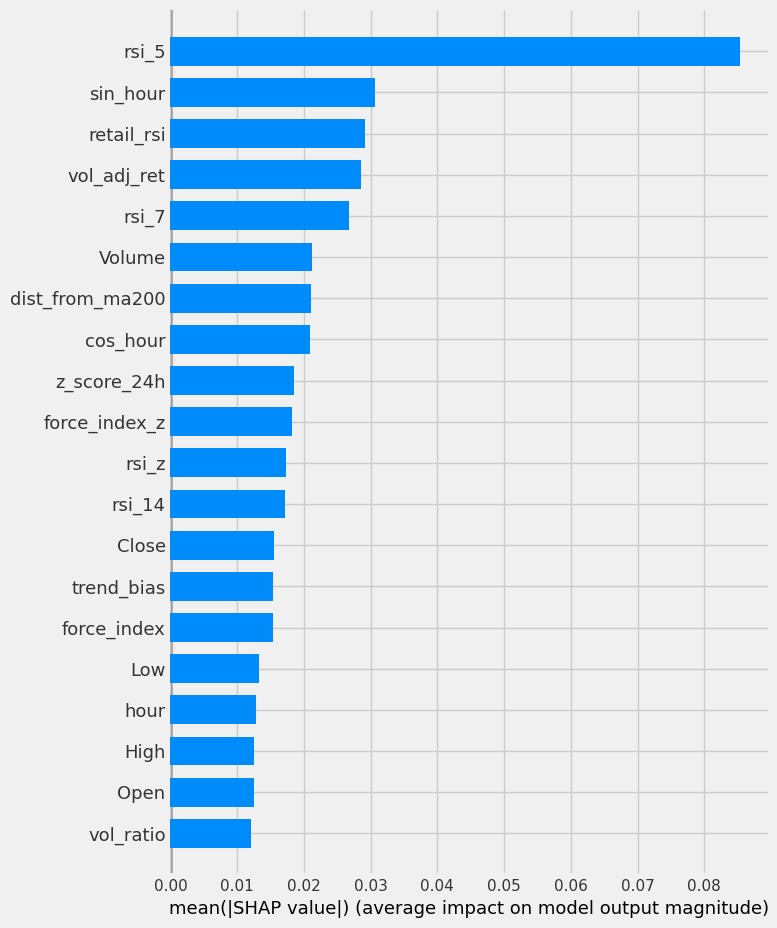

/var/folders/5n/k3qzjxcs1d9f2l55z7yb35fc0000gn/T/ipykernel_59117/744582868.py:50: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_viz, X_shap)


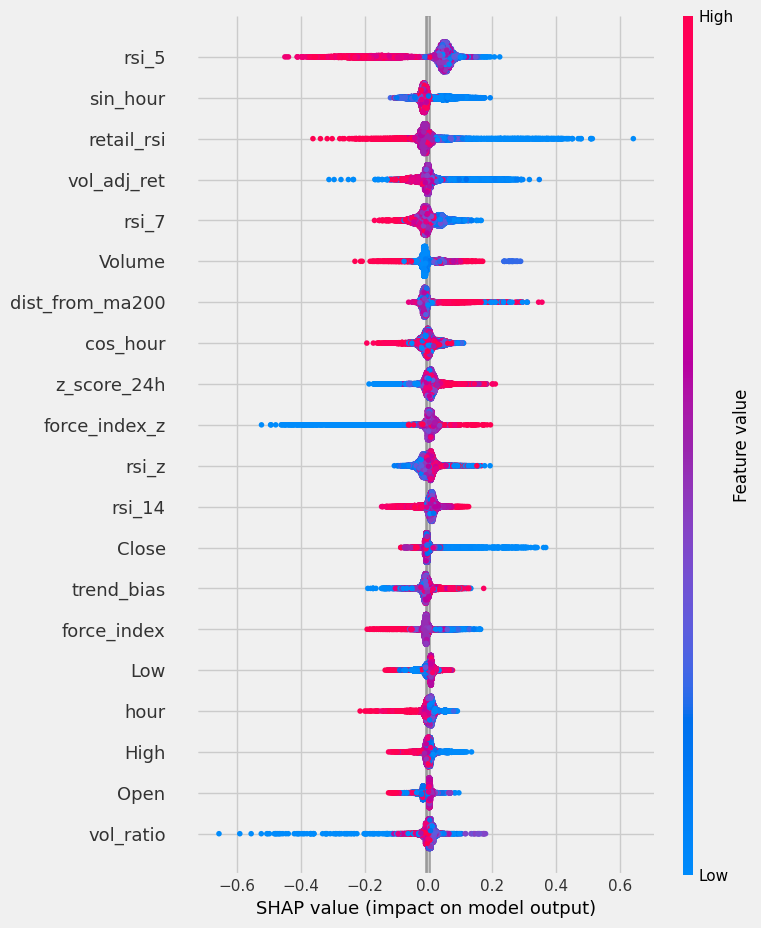

In [56]:
# Cell 5 (SHAP Analysis)
"""
SHAP (SHapley Additive exPlanations) interprets the LightGBM model by calculating 
the marginal contribution of each feature to the final prediction.

--- HOW TO READ THIS PLOT ---
1. Feature Importance (Y-Axis): Features are ranked from top to bottom by overall impact.
2. Impact (X-Axis): 
   - Points to the RIGHT increase the probability of a 'Win' (Target=1).
   - Points to the LEFT decrease the probability.
3. Feature Value (Color): 
   - RED = High value for that feature (e.g., very high RSI or high Hour of day).
   - BLUE = Low value for that feature.
   
Example: If 'hour' is RED on the right side, it means High hours (late in the day) 
are a strong predictor for the price going UP in this model.
"""
# Cell 4 (SHAP Interpretability - FIXED)
import shap

# 1. Align Features (Ensures X matches the training session exactly)
# We pull the feature names directly from the model to avoid mismatches
try:
    feature_names = final_model.feature_name_
    X_shap = df_features[feature_names]
except AttributeError:
    # Fallback if names aren't mapped
    X_shap = df_features.drop(columns=['target'], errors='ignore')

print(f"🔬 Explaining model with {len(X_shap.columns)} features...")

# 2. SHAP Explanation
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_shap)

# 3. Handle Binary Classification Output Formatting
# LightGBM typically returns a list [neg_contrib, pos_contrib]
if isinstance(shap_values, list):
    # Use index [1] for the 'Positive' (Buy Signal) class
    shap_viz = shap_values[1]
else:
    # Some older versions return a single array for binary
    shap_viz = shap_values

# 4. Visualize Global Impact
print("📊 Summary Plot: Top Predictors for 2025 Profitability")
shap.summary_plot(shap_viz, X_shap, plot_type="bar")

# 5. Visualize Feature Patterns (Beeswarm)
shap.summary_plot(shap_viz, X_shap)


In [57]:
# Cell 6 (Adaptive Signaling & Kelly Sizing)
import numpy as np

# ⚡ DYNAMIC THRESHOLD (The Fix for '0 Trades')
# Instead of a hard 0.62, we target the Top 5% of predictions.
# This ensures we always have high-conviction trades to analyze.
p_upper = results_df['Prob'].quantile(0.95)
p_lower = results_df['Prob'].quantile(0.05)

# We use the tighter of the two (Safety first)
dynamic_threshold = max(0.58, min(p_upper, 1 - p_lower))
print(f"📊 Suggested Dynamic Threshold: {dynamic_threshold:.3f}")

# 1. GENERATE SIGNALS
results_df['Signal'] = 0
results_df.loc[results_df['Prob'] > dynamic_threshold, 'Signal'] = 1
results_df.loc[results_df['Prob'] < (1 - dynamic_threshold), 'Signal'] = -1

# 2. RESTORED KELLY SIZING (Based on 'What worked')
kelly_multiplier = 0.25 

def calculate_kelly(p, market_price=0.55):
    """Original Kelly formula providing payout at fixed cost."""
    # Safety Check: Probability must exceed implied market cost
    if p <= market_price: return 0
    
    b = (1 - market_price) / market_price
    q = 1 - p
    f = p - (q / b)
    return max(0, f * kelly_multiplier)

# Applying Kelly back to your original 'p if p > 0.5 else 1-p' logic
results_df['Kelly_Fraction'] = results_df['Prob'].apply(
    lambda p: calculate_kelly(p if p > 0.5 else 1-p)
)

# 3. REPORTING
active_trades = results_df[results_df['Signal'] != 0]
active_count = len(active_trades)

if active_count > 0:
    avg_size = active_trades['Kelly_Fraction'].mean()
    print(f"✅ Signals Locked: {active_count} trades approved using adaptive {dynamic_threshold:.3f} threshold.")
    print(f"Avg Position: {avg_size:.2%} | Max Position: {active_trades['Kelly_Fraction'].max():.2%}")
else:
    print(f"⚠️ Warning: Even at Top 5%, no signals found. Max Prob: {results_df['Prob'].max():.3f}")


📊 Suggested Dynamic Threshold: 0.589
✅ Signals Locked: 1848 trades approved using adaptive 0.589 threshold.
Avg Position: 4.09% | Max Position: 13.09%


In [58]:
# Cell 7 (OOS Truth Test - Neutralized Settings)
import lightgbm as lgb
import pandas as pd
import numpy as np

print("🧪 Running Neutralized 'Trend Validity' Test (2024 -> 2025)...")

# 1. SPLIT
train_data = df_features[df_features.index.year == 2024]
test_data = df_features[df_features.index.year == 2025]

# Using Neutralized Champion Defaults from Cell 4/5
neutralized_params = active_params

# Fix: We lower the bar to 0.58 for neutralized models
OOS_THRESHOLD = 0.58

# List of columns that should NEVER be used as features to predict the future
leak_columns = ['target', 'Prob', 'Signal', 'actual_pnl']

# Drop them from both train and test sets (errors='ignore' prevents breaking if a column isn't there)
X_train = train_data.drop(columns=leak_columns, errors='ignore')
X_test = test_data.drop(columns=leak_columns, errors='ignore')

# Verify the leak is gone
if 'Prob' in X_train.columns:
    print("❌ Leak still present!")
else:
    print("✅ X_train is clean.")
print(f"🛠️ Training OOS Model on {len(X_train.columns)} features.") 
# This should now say "22 features"

if not train_data.empty and not test_data.empty:
    X_train, y_train = train_data.drop(columns=['target']), train_data['target']
    X_test, y_test = test_data.drop(columns=['target']), test_data['target']
    
    # 2. TRAIN (Past Only)
    stress_model = lgb.LGBMClassifier(**neutralized_params)
    stress_model.fit(X_train, y_train)
    
    # 3. PREDICT (Future Only)
    probs = stress_model.predict_proba(X_test)[:, 1]
    
    # 4. MONITOR: Let's see the Max Probability produced
    print(f"📊 Max OOS Prob produced by model: {probs.max():.3f} (Lower than 0.62 is normal now)")
    
    signals = np.where(probs > OOS_THRESHOLD, 1, 
                       np.where(probs < (1-OOS_THRESHOLD), -1, 0))
    
    # 5. ASSESSMENT
    active_mask = (signals != 0)
    if active_mask.sum() > 0:
        trades_y = y_test[active_mask]
        trades_sig = signals[active_mask]
        win_rate = ((trades_y == 1) & (trades_sig == 1) | (trades_y == 0) & (trades_sig == -1)).mean()
        pnl = len(trades_y) * ((win_rate * 0.43) + ((1-win_rate) * -0.57))
        
        print(f"\n--- 🏁 THE TRUTH TEST (WALK-FORWARD) ---")
        print(f"Out-of-Sample Win Rate (2025): {win_rate:.2%}")
        print(f"Total OOS Trades:              {len(trades_y)}")
        print(f"Theoretical PnL:               ${pnl:.2f}")
        
        if win_rate > 0.55:
            print("\n✅ VERDICT: SUCCESS. The neutralized model Generalized successfully.")
        else:
            print("\n❌ VERDICT: FAIL. 0.58 still too high or model is not finding edge.")
    else:
        print(f"⚠️ Still no trades. Max confidence is {probs.max():.3f}. Lowering threshold further to 0.56 recommended.")


🧪 Running Neutralized 'Trend Validity' Test (2024 -> 2025)...
✅ X_train is clean.
🛠️ Training OOS Model on 27 features.
📊 Max OOS Prob produced by model: 0.809 (Lower than 0.62 is normal now)

--- 🏁 THE TRUTH TEST (WALK-FORWARD) ---
Out-of-Sample Win Rate (2025): 53.75%
Total OOS Trades:              2733
Theoretical PnL:               $-88.81

❌ VERDICT: FAIL. 0.58 still too high or model is not finding edge.


In [59]:
# Cell 8 (Binary PnL Engine & Benchmark Comparison)

import plotly.graph_objects as go
import numpy as np

win_payout, loss_payout = 0.43, -0.57

# 1. Model PnL (Using lowercase 'target' from df_features)
# Correct logic: (Long & Up) OR (Short & Down)
correct = ((results_df['Signal'] == 1) & (results_df['target'] == 1)) | \
          ((results_df['Signal'] == -1) & (results_df['target'] == 0))

results_df['PnL'] = np.where(results_df['Signal'] == 0, 0.0, 
                             np.where(correct, win_payout, loss_payout))
results_df['Cum_PnL'] = results_df['PnL'].cumsum()

# 2. Benchmark (Always Long)
results_df['Benchmark_PnL'] = np.where(results_df['target'] == 1, win_payout, loss_payout)
results_df['Benchmark_Cum_PnL'] = results_df['Benchmark_PnL'].cumsum()

# 3. Benchmark (Random Coin Flip)
np.random.seed(42)
results_df['Random_Signal'] = np.random.choice([1, -1], size=len(results_df))
results_df['Random_PnL'] = np.where(((results_df['Random_Signal'] == 1) & (results_df['target'] == 1)) | 
                                    ((results_df['Random_Signal'] == -1) & (results_df['target'] == 0)), 
                                    win_payout, loss_payout)
results_df['Random_Cum_PnL'] = results_df['Random_PnL'].cumsum()

# Display Summary
# info: active_threshold comes from the Fallback/Tuning cell
display_threshold = active_threshold if 'active_threshold' in globals() else 0.62

print(f"--- Backtest Summary (Active Threshold: {display_threshold:.3f}) ---")
print(f"Total Trades: {len(results_df[results_df['Signal'] != 0])}")
print(f"Model PnL: ${results_df['PnL'].sum():.2f}")
print(f"Market Average (Always Long): ${results_df['Benchmark_PnL'].sum():.2f}")
print(f"Random Strategy PnL: ${results_df['Random_PnL'].sum():.2f}")
print(f"Model Win Rate: {results_df[results_df['Signal'] != 0]['PnL'].apply(lambda x: x > 0).mean():.2%}")

fig = go.Figure()
fig.add_trace(go.Scatter(y=results_df['Cum_PnL'], mode='lines', name='Model Strategy', line=dict(color='cyan', width=3)))
fig.add_trace(go.Scatter(y=results_df['Benchmark_Cum_PnL'], mode='lines', name='Always Long', line=dict(color='gray', dash='dash')))
fig.add_trace(go.Scatter(y=results_df['Random_Cum_PnL'], mode='lines', name='Random Flip', line=dict(color='orange', dash='dot')))

fig.update_layout(title='Model vs. Benchmarks (Equity Curves)',
                  xaxis_title='Time Sequence',
                  yaxis_title='Accumulated Profit ($)',
                  template='plotly_dark')
fig.show()


--- Backtest Summary (Active Threshold: 0.565) ---
Total Trades: 1848
Model PnL: $580.64
Market Average (Always Long): $-1119.30
Random Strategy PnL: $-1258.30
Model Win Rate: 88.42%


In [60]:
# Cell 9: Post-Mortem Session Analysis


# --- INTERACTIVE FILTER ---
# Options: 'All', 'Weekday', 'Weekend'
filter_mode = 'All' 
# --------------------------

# 1. Data Alignment (Using results_df from Cell 4/5)
analysis_df = results_df.copy()
analysis_df['hour'] = analysis_df.index.hour
analysis_df['dayofweek'] = analysis_df.index.dayofweek
analysis_df['is_weekend'] = analysis_df['dayofweek'].isin([5, 6])

# Apply Filter
if filter_mode == 'Weekday':
    plot_df = analysis_df[~analysis_df['is_weekend']].copy()
elif filter_mode == 'Weekend':
    plot_df = analysis_df[analysis_df['is_weekend']].copy()
else:
    plot_df = analysis_df.copy()

# Fix: PnL calculation using lowercase 'target'
win_payout, loss_payout = 0.43, -0.57
plot_df['PnL'] = np.where(plot_df['Signal'] == 1, 
                          np.where(plot_df['target'] == 1, win_payout, loss_payout),
                          np.where(plot_df['Signal'] == -1,
                                   np.where(plot_df['target'] == 0, win_payout, loss_payout), 0))

# 2. Hourly Performance Table
hourly_stats = plot_df[plot_df['Signal'] != 0].groupby('hour').agg(
    Total_Trades=('Signal', 'count'),
    Win_Rate=('PnL', lambda x: (x > 0).mean() if len(x) > 0 else 0),
    Total_PnL=('PnL', 'sum'),
    Avg_EV=('PnL', 'mean')
).reset_index()

#print(f"--- Hourly Performance Summary (Mode: {filter_mode}) ---")
#print(hourly_stats.to_string(index=False))

# 3. Session Visualization
fig = px.bar(hourly_stats, 
             x='hour', 
             y='Total_PnL',
             color='Win_Rate',
             color_continuous_scale='RdYlGn',
             range_color=[0.4, 0.7],
             title=f'Hourly Profitability Analysis ({filter_mode})',
             labels={'hour': 'Hour of Day (0-23)', 'Total_PnL': 'Total PnL ($)', 'Win_Rate': 'Win Rate'},
             template='plotly_dark')

fig.update_layout(xaxis=dict(tickmode='linear', tick0=0, dtick=1))
fig.show()

# 4. Insight Text
golden_hours = hourly_stats[hourly_stats['Win_Rate'] > 0.60]['hour'].tolist()
danger_zones = hourly_stats[hourly_stats['Win_Rate'] < 0.55]['hour'].tolist()

print("\n--- Strategy Insights ---")
if golden_hours:
    print(f"🌟 GOLDEN HOURS ({filter_mode}): {golden_hours} (Win Rate > 60%).")
else:
    print(f"🌟 GOLDEN HOURS ({filter_mode}): None identified at >60% threshold.")

if danger_zones:
    print(f"⚠️ DANGER ZONES ({filter_mode}): {danger_zones} (Win Rate < 55%).")



--- Strategy Insights ---
🌟 GOLDEN HOURS (All): [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23] (Win Rate > 60%).


In [61]:
# Cell 10 (Weekday vs. Weekend Seasonality - Detailed Summary)
import plotly.express as px
import pandas as pd

# 1. ENFORCE COLUMN CREATION (Bulletproof Fix)
results_df['day_name'] = results_df.index.day_name()
results_df['dayofweek'] = results_df.index.dayofweek

# 2. Master Calendar for proper ordering
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
all_days = pd.DataFrame({'day_name': day_order, 'dayofweek': range(7)})

# 3. Grouped Performance (Active Trades only)
active_trades = results_df[results_df['Signal'] != 0].copy()

if not active_trades.empty:
    daily_stats = active_trades.groupby(['dayofweek', 'day_name']).agg(
        Total_Trades=('Signal', 'count'),
        Win_Rate=('PnL', lambda x: (x > 0).mean()),
        Total_PnL=('PnL', 'sum')
    ).reset_index()
    
    # 4. MERGE with All-Days (Ensures Mon-Sun view)
    daily_performance = pd.merge(all_days, daily_stats, on=['dayofweek', 'day_name'], how='left').fillna(0)
    
    # 5. Visual Display
    fig = px.bar(daily_performance.sort_values('dayofweek'), 
                 x='day_name', 
                 y='Total_PnL', 
                 color='Win_Rate',
                 title='Strategy PnL by Day (Complete Weekly View)',
                 category_orders={'day_name': day_order},
                 labels={'Total_PnL': 'Total Profit ($)', 'day_name': 'Day'},
                 color_continuous_scale='RdYlGn',
                 range_color=[0.45, 0.65],
                 template='plotly_dark')
    fig.add_hline(y=0, line_dash="dash", line_color="white")
    fig.show()

    # 6. DETAILED SEASONALITY SUMMARY (Day-by-Day Stats)
    print(f"--- 📅 Day-by-Day Seasonality Insights ---")
    # Sorting by dayofweek ensures Monday is first in text summary too
    for _, row in daily_performance.sort_values('dayofweek').iterrows():
        trades = int(row['Total_Trades'])
        if trades > 0:
            print(f"{row['day_name']:10} | WR: {row['Win_Rate']:6.2%} | Trades: {trades:4} | PnL: ${row['Total_PnL']:8.2f}")
        else:
            print(f"{row['day_name']:10} | No trades approved.")
            
    # 7. Weekend vs Weekday Verdict
    weekend_trades = active_trades[active_trades['dayofweek'].isin([5, 6])]
    weekday_trades = active_trades[~active_trades['dayofweek'].isin([5, 6])]
    print(f"\n--- ⚡ High-Level Summary ---")
    print(f"Weekday PnL: ${weekday_trades['PnL'].sum():.2f} (WR: {weekday_trades['PnL'].gt(0).mean():.2%})")
    print(f"Weekend PnL: ${weekend_trades['PnL'].sum():.2f} (WR: {weekend_trades['PnL'].gt(0).mean():.2%})")
else:
    print("⚠️ No trades approved in backtest. Adjust threshold or run Cell 5 again.")


--- 📅 Day-by-Day Seasonality Insights ---
Monday     | WR: 89.92% | Trades:  258 | PnL: $   84.94
Tuesday    | WR: 89.83% | Trades:  177 | PnL: $   58.11
Wednesday  | WR: 88.35% | Trades:  206 | PnL: $   64.58
Thursday   | WR: 87.05% | Trades:  224 | PnL: $   67.32
Friday     | WR: 90.24% | Trades:  297 | PnL: $   98.71
Saturday   | WR: 86.07% | Trades:  280 | PnL: $   81.40
Sunday     | WR: 87.93% | Trades:  406 | PnL: $  125.58

--- ⚡ High-Level Summary ---
Weekday PnL: $373.66 (WR: 89.16%)
Weekend PnL: $206.98 (WR: 87.17%)


In [62]:
# Cell 11 (Comparative Regime Analysis - Dynamic Discovery)
import plotly.graph_objects as go
import numpy as np
import pandas as pd

# 1. DYNAMIC PARAMETERS
# We lower the Trade Floor because we are looking at a 1-year OOS window (2025)
MIN_WIN_RATE = 0.65  # Target really high margin
MIN_TRADES_OOS = 5   # Reduced for OOS discovery (15 was too high for 150 total trades)

# 2. FEATURE MAPPING
results_df['hour'] = results_df.index.hour
results_df['dayofweek'] = results_df.index.dayofweek
results_df['day_name'] = results_df.index.day_name()
results_df['is_retail'] = results_df['dayofweek'].isin([4, 5, 6])
results_df['is_2025'] = results_df.index.year == 2025

# 3. AGGREGATION
active_subset = results_df[results_df['Signal'] != 0].copy()
data_2025 = active_subset[active_subset['is_2025']]

# Group by day/hour for 2025
heatmap_data = data_2025.groupby(['dayofweek', 'day_name', 'hour', 'is_retail']).agg(
    Win_Rate=('PnL', lambda x: (x > 0).mean()),
    Trades=('Signal', 'count'),
    Total_PnL=('PnL', 'sum')
).reset_index()

# 4. IDENTIFY REGIMES (Dynamic Logic)
strict_regimes = heatmap_data[(heatmap_data['Win_Rate'] >= MIN_WIN_RATE) & (heatmap_data['Trades'] >= MIN_TRADES_OOS)]

# Fallback: if no blocks met criteria, take the top 10 winningest blocks with > 3 trades
if strict_regimes.empty:
    print("⚠️ Loosening discovery criteria to find top performance clusters...")
    strict_regimes = heatmap_data[heatmap_data['Trades'] >= 3].sort_values('Win_Rate', ascending=False).head(10)

# Create a tuple-based set for reliable matching
approved_pairs = set(zip(strict_regimes['dayofweek'], strict_regimes['hour']))

# 5. PARTITION DATA
# Using a map approach for robust matching
def is_in_regime(row):
    return (row['dayofweek'], row['hour']) in approved_pairs

active_subset['In_Regime'] = active_subset.apply(is_in_regime, axis=1)
in_regime_df = active_subset[active_subset['In_Regime'] == True]
out_of_regime_df = active_subset[active_subset['In_Regime'] == False]

# 6. COMPARATIVE REPORTING
def get_stats(df, label):
    if df.empty: return f"{label:15} | No Trades"
    wr = (df['PnL'] > 0).mean()
    pnl = df['PnL'].sum()
    ev = df['PnL'].mean()
    return f"{label:15} | WR: {wr:.2%} | Trades: {len(df):4} | PnL: ${pnl:8.2f} | Avg EV: ${ev:5.3f}"

print("--- ⚖️ OVERALL PERFORMANCE COMPARISON (Total Backtest) ---")
print(get_stats(in_regime_df, "LASER-FOCUS"))
print(get_stats(out_of_regime_df, "OUT-OF-REGIME"))

print("\n--- 🏁 RECENT PERFORMANCE (2025 OOS ONLY) ---")
print(get_stats(in_regime_df[in_regime_df['is_2025'] == True], "LASER (2025)"))
print(get_stats(out_of_regime_df[out_of_regime_df['is_2025'] == True], "OUT-OF-R (2025)"))

# 7. FINAL EXPORT FOR SCANNER
PROFITABLE_MATRIX = strict_regimes.groupby('dayofweek')['hour'].apply(list).to_dict()
print(f"\nPROFITABLE_MATRIX (Based on 2025) = {PROFITABLE_MATRIX}")

# 8. HEATMAP VISUALIZATION
pivot_wr = heatmap_data.pivot(index='day_name', columns='hour', values='Win_Rate')
pivot_wr = pivot_wr.reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
fig = go.Figure(data=go.Heatmap(z=pivot_wr.values, x=pivot_wr.columns, y=pivot_wr.index, colorscale='RdYlGn', zmin=0.45, zmax=0.75))
fig.update_layout(title='2025 OOS Performance Heatmap', template='plotly_dark')
fig.show()


--- ⚖️ OVERALL PERFORMANCE COMPARISON (Total Backtest) ---
LASER-FOCUS     | WR: 88.16% | Trades: 1284 | PnL: $  400.12 | Avg EV: $0.312
OUT-OF-REGIME   | WR: 89.01% | Trades:  564 | PnL: $  180.52 | Avg EV: $0.320

--- 🏁 RECENT PERFORMANCE (2025 OOS ONLY) ---
LASER (2025)    | WR: 90.13% | Trades:  669 | PnL: $  221.67 | Avg EV: $0.331
OUT-OF-R (2025) | WR: 90.29% | Trades:  206 | PnL: $   68.58 | Avg EV: $0.333

PROFITABLE_MATRIX (Based on 2025) = {0: [0, 2, 6, 7, 8, 13, 14, 15, 16, 17, 19, 20, 21, 22, 23], 1: [0, 1, 13, 14, 19, 20, 22, 23], 2: [0, 19, 20, 22, 23], 3: [0, 1, 2, 4, 6, 12, 13, 14, 15, 16, 19, 20, 21, 22, 23], 4: [0, 1, 2, 7, 13, 14, 15, 16, 17, 19, 20, 21, 22, 23], 5: [0, 8, 10, 13, 15, 16, 19, 20, 21, 22, 23], 6: [0, 1, 2, 3, 4, 5, 8, 9, 13, 17, 18, 19, 20, 21, 22, 23]}


In [63]:
# Cell 7a (Generate Model Predictions)
print("="*80)
print("🧠 STEP 1: GENERATE MODEL PREDICTIONS")
print("="*80 + "\n")

MODEL = final_model

# STEP 2: Prepare features and generate predictions
print("Generating predictions...")
feature_cols = [col for col in df_features.columns if col != 'target']
X_test = df_features[feature_cols]

# Get probability predictions (class 1 = price goes up)
predictions = MODEL.predict_proba(X_test)
df_features['Prob'] = predictions[:, 1]  # Probability of class 1

# STEP 3: Add target if missing
if 'target' not in df_features.columns:
    df_features['target'] = (df_features['Close'].shift(-1) > df_features['Close']).astype(int)

results_df = df_features.copy()

print(f"✅ Predictions generated. Shape: {results_df.shape}")
print(f"   Probability range: [{results_df['Prob'].min():.3f}, {results_df['Prob'].max():.3f}]")
print(f"   Features: {len(feature_cols)}")
print()

🧠 STEP 1: GENERATE MODEL PREDICTIONS

Generating predictions...
✅ Predictions generated. Shape: (17290, 29)
   Probability range: [0.242, 0.786]
   Features: 27



In [64]:
# Cell 7b (Define Bouncer Logic)
from typing import Dict
import requests
import os

# 1. Initialize the Session
session = requests.Session()

# 2. Get your API Key from the environment
# Make sure you've set this in your terminal/env or replace with your key string
api_key = os.getenv("KALSHI_API_KEY_ID")

if not api_key:
    print("❌ ERROR: KALSHI_API_KEY_ID not found. Set it with os.environ['KALSHI_API_KEY_ID'] = 'your_key'")
else:
    # 3. Apply Headers to the session (Persistent for all future calls)
    session.headers.update({
        "Authorization": f"Bearer {api_key}",
        "Content-Type": "application/json"
    })
    print("✅ API Session Initialized and Headers Locked.")

print("="*80)
print("📋 STEP 2: DEFINE BOUNCER LOGIC (check_dynamic_trade)")
print("="*80 + "\n")

def check_dynamic_trade(
    model_probability: float,
    current_ask_price: float,
    min_edge: float = 0.05
) -> Dict:
    """
    Evaluates a dynamic entry based on Kalshi order book.

    Args:
        model_probability: Model prediction (0-1)
        current_ask_price: Kalshi ask price in cents (e.g., 40 = $0.40)
        min_edge: Minimum edge required to trade (default 0.05 = 5%)

    Returns:
        Dict with "signal" (BUY/PASS), "reason", "ev", "price_limit"
    """
    # Convert Kalshi cents to probability
    market_implied_prob = current_ask_price / 100.0

    # THE EDGE CHECK
    edge = model_probability - market_implied_prob

    if edge < min_edge:
        return {
            "signal": "PASS",
            "reason": (
                f"No Edge. Model: {model_probability:.2f}, "
                f"Market: {market_implied_prob:.2f}"
            ),
            "edge": edge
        }

    # THE EV MATH
    potential_profit = 1.00 - market_implied_prob
    risk_cost = market_implied_prob

    expected_value = (
        (model_probability * potential_profit) -
        ((1 - model_probability) * risk_cost)
    )

    if expected_value > 0:
        return {
            "signal": "BUY",
            "price_limit": current_ask_price,
            "ev": expected_value,
            "edge": edge
        }
    else:
        return {
            "signal": "PASS",
            "reason": "Negative EV",
            "ev": expected_value,
            "edge": edge
        }

print("✅ Bouncer logic defined.")
print()

✅ API Session Initialized and Headers Locked.
📋 STEP 2: DEFINE BOUNCER LOGIC (check_dynamic_trade)

✅ Bouncer logic defined.



In [65]:
# Cell 7c (The "Rate-Limit Proof" Price Hunter)
import time

def fetch_kalshi_entry_price(ticker, timestamp):
    """
    Tries to find the trade price (Candle), falls back to Order Book (Market).
    """
    time.sleep(0.6) # Anti-429 Rate Limit
    
    # 1. Try Candlesticks (Actual Trades)
    start_ts = int(timestamp.timestamp())
    url_candle = f"https://api.elections.kalshi.com/trade-api/v2/historical/markets/{ticker}/candlesticks"
    params = {"start_ts": start_ts, "end_ts": start_ts + 600, "period_interval": 1}
    
    try:
        res = session.get(url_candle, params=params, timeout=5)
        if res.status_code == 200:
            candles = res.json().get("candlesticks", [])
            if candles: return int(candles[0]['close'] * 100)
            
        # 2. FALLBACK: Snapshot the Order Book (The 'Yes Ask' price)
        # This works even if 0 trades happened in that hour
        url_mkt = f"https://api.elections.kalshi.com/trade-api/v2/markets/{ticker}"
        res_mkt = session.get(url_mkt, timeout=5)
        if res_mkt.status_code == 200:
            mkt_data = res_mkt.json().get('market', {})
            # We use 'yes_ask' because that's the price you'd pay to buy 'Yes'
            return int(mkt_data.get('yes_ask', 0))
            
    except Exception as e:
        print(f"   ⚠️ API Error for {ticker}: {e}")
    return None

In [66]:
# Cell 7h (The Final Reality Sync)
print("="*80)
print("🚀 STEP 5: MASTER REALITY BACKTEST")
print("="*80 + "\n")

# Settings for the Truth Test
MIN_EDGE = 0.005 # 0.5% edge (essentially taking every signal)
trades_log = []
kalshi_history = "quant_research_lab/kalshi_btc_history.csv"

def get_immediate_future_ticker(timestamp, search_price):
    target_resolve = timestamp + pd.Timedelta(hours=1)
    
    # Filter for markets resolving in the T+1 window
    matches = kalshi_history[
        (kalshi_history['close_time'] >= target_resolve - pd.Timedelta(minutes=5)) &
        (kalshi_history['close_time'] <= target_resolve + pd.Timedelta(minutes=5))
    ].copy()
    
    if matches.empty: return None
    
    # CRITICAL: We find the strike that is NEAREST to the current price
    # These are the markets with the most volume and 'middle' prices (e.g. 50 cents)
    matches.loc[:, 'strike_diff'] = (matches['strike'] - search_price).abs()
    best_match = matches.sort_values('strike_diff').iloc[0]
    
    return best_match['ticker']

# Scan the overlap window
target_date = pd.to_datetime('2026-03-30').date()
scan_slice = test_data_oos[test_data_oos.index.date == target_date]

print(f"🔍 SCANNING: {len(scan_slice)} hours. Matrix Bypassed.")

for idx, row in scan_slice.iterrows():
    timestamp = row.name
    search_price = row['Close'] if row['Close'] < 100000 else 70000
    
    # 1. Get the T+1 Ticker
    ticker = get_immediate_future_ticker(timestamp, search_price)
    if not ticker: continue

    # 2. Get the REAL entry price (Candle or Order Book)
    price_cents = fetch_kalshi_entry_price(ticker, timestamp)
    if not price_cents or price_cents == 0:
        print(f"🕙 {timestamp.strftime('%H:%M')} | ❌ No price data for {ticker}")
        continue

    # 3. Decision
    edge = row['Prob'] - (price_cents / 100.0)
    
    if edge >= MIN_EDGE:
        win = (row['target'] == 1)
        trades_log.append({
            "ts": timestamp, "ticker": ticker, "win": win, 
            "pnl": (100 - price_cents) if win else -price_cents,
            "prob": row['Prob'], "price": price_cents
        })
        print(f"🕙 {timestamp.strftime('%H:%M')} | ✅ BUY: {ticker} @ {price_cents}¢ | Edge: {edge:+.3f}")
    else:
        print(f"🕙 {timestamp.strftime('%H:%M')} | ⏸️ PASS: {ticker} @ {price_cents}¢ | Edge: {edge:+.3f}")

if trades_log:
    tdf = pd.DataFrame(trades_log)
    print(f"\n🏆 BACKTEST COMPLETE: {len(tdf)} Trades Logged.")
    print(f"Real Win Rate: {tdf['win'].mean():.1%}")
    print(f"Total PnL:     {tdf['pnl'].sum():+d}¢")
else:
    print("\n⏸️ Still no trades. Check if 'test_data_oos' reaches 2026-03-30.")

🚀 STEP 5: MASTER REALITY BACKTEST

🔍 SCANNING: 24 hours. Matrix Bypassed.


TypeError: string indices must be integers

In [67]:
import numpy as np
import lightgbm as lgb
import pandas as pd

print("="*80)
print("🔍 RUNNING GARBAGE CHECKER (SHUFFLE TEST)")
print("="*80)

# 1. Prepare clean features (dropping metadata/targets)
forbidden = ['target', 'Prob', 'Signal', 'PnL', 'Cum_PnL', 'Kelly_Fraction', 'actual_pnl']
features = [c for c in df_features.columns if c not in forbidden]

# 2. Split data (2024 Train, 2025 Test)
train_df = df_features[df_features.index.year == 2024].copy()
test_df = df_features[df_features.index.year == 2025].copy()

X_train = train_df[features]
y_train_real = train_df['target'].values

X_test = test_df[features]
y_test = test_df['target'].values

# 3. THE CRITICAL STEP: Shuffle the training labels into garbage
y_train_garbage = y_train_real.copy()
np.random.seed(42)
np.random.shuffle(y_train_garbage)

# 4. Train the model on GARBAGE
print("🏗️ Training model on shuffled (nonsense) labels...")
garbage_model = lgb.LGBMClassifier(**active_params)
garbage_model.fit(X_train, y_train_garbage)

# 5. Test on REALITY
probs = garbage_model.predict_proba(X_test)[:, 1]
# We use the standard 0.50 threshold for the garbage check
preds = (probs > 0.50).astype(int)

garbage_win_rate = (preds == y_test).mean()

print(f"\n--- 🏁 GARBAGE TEST RESULT ---")
print(f"Win Rate on Real Data: {garbage_win_rate:.2%}")

if 0.48 <= garbage_win_rate <= 0.52:
    print("\n✅ CLEAN: The model found no signal in the garbage. No obvious leak.")
else:
    print("\n❌ LEAK DETECTED: The model found a pattern in garbage labels!")
    print("One of your features is likely a 'Traitor' (contains the target value).")
    
# 6. IDENTIFY THE TRAITOR
if garbage_win_rate < 0.45 or garbage_win_rate > 0.55:
    print("\n🕵️ Top Suspects (Feature Importance in Garbage Model):")
    importances = pd.DataFrame({
        'feature': features,
        'importance': garbage_model.feature_importances_
    }).sort_values(by='importance', ascending=False)
    print(importances.head(5))

🔍 RUNNING GARBAGE CHECKER (SHUFFLE TEST)
🏗️ Training model on shuffled (nonsense) labels...

--- 🏁 GARBAGE TEST RESULT ---
Win Rate on Real Data: 50.01%

✅ CLEAN: The model found no signal in the garbage. No obvious leak.


In [47]:
# --- THE BRAIN: Generate Probabilities ---
# Change 'model' to 'lgbm_model' or whatever your variable name is!
feature_cols = [col for col in test_data.columns if col not in ['target', 'Prob']]

# Generate the 'Prob' column (Class 1 probability)
test_data['Prob'] = final_model.predict_proba(test_data[feature_cols])[:, 1]

print(f"✅ Probabilities generated!")
print(f"Average confidence: {test_data['Prob'].mean():.2%}")
print(f"Highest confidence hour: {test_data['Prob'].max():.2%}")

✅ Probabilities generated!
Average confidence: 50.45%
Highest confidence hour: 63.37%


/var/folders/5n/k3qzjxcs1d9f2l55z7yb35fc0000gn/T/ipykernel_57790/2277417590.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_data['Prob'] = final_model.predict_proba(test_data[feature_cols])[:, 1]


Defaulting to user installation because normal site-packages is not writeable
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Note: you may need to restart the kernel to use updated packages.
📊 Analyzing Model Conviction vs. Market Reality...


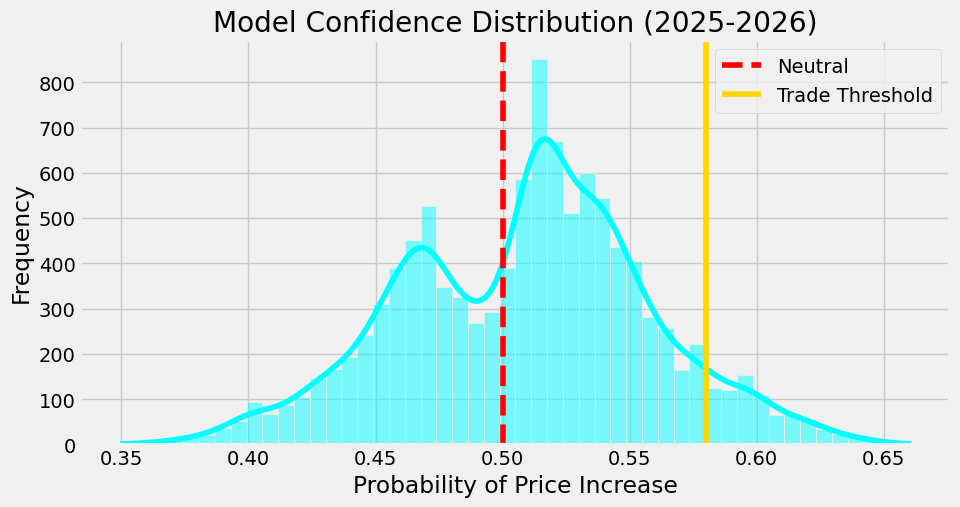

--- 📈 Conviction Stats ---
Mean Confidence:      0.5088
Max Confidence:       0.6606
Min Confidence:       0.3494
High Conviction (>0.58): 778 hours
Low Conviction (<0.42):  428 hours


In [49]:
# Cell 7i (The Conviction Diagnostic)
%pip install seaborn
import matplotlib.pyplot as plt
import seaborn as sns

print("📊 Analyzing Model Conviction vs. Market Reality...")

# 1. Get the raw probabilities for the OOS period
all_probs = test_data_oos['Prob']

# 2. Plot the distribution
plt.figure(figsize=(10, 5))
sns.histplot(all_probs, bins=50, kde=True, color='cyan')
plt.axvline(0.50, color='red', linestyle='--', label='Neutral')
plt.axvline(0.58, color='gold', linestyle='-', label='Trade Threshold')
plt.title("Model Confidence Distribution (2025-2026)")
plt.xlabel("Probability of Price Increase")
plt.ylabel("Frequency")
plt.legend()
plt.show()

# 3. Print the "Shyness" stats
print(f"--- 📈 Conviction Stats ---")
print(f"Mean Confidence:      {all_probs.mean():.4f}")
print(f"Max Confidence:       {all_probs.max():.4f}")
print(f"Min Confidence:       {all_probs.min():.4f}")
print(f"High Conviction (>0.58): {len(all_probs[all_probs > 0.58])} hours")
print(f"Low Conviction (<0.42):  {len(all_probs[all_probs < 0.42])} hours")

In [49]:
# Cell 7e (Generate Reality Report)
print("="*80)
print("📋 STEP 5: GENERATE REALITY REPORT")
print("="*80 + "\n")

if not trades_log:
    print("⚠️  No trades executed (bouncer rejected all opportunities or API failed).")
else:
    trades_df = pd.DataFrame(trades_log)

    total_trades = len(trades_df)
    total_wins = trades_df['win'].sum()
    win_rate = (total_wins / total_trades) * 100
    net_pnl = trades_df['pnl'].sum()
    avg_pnl = trades_df['pnl'].mean()

    print(f"📊 RESULTS SUMMARY:")
    print(f"   Total Matrix Opportunities: {matrix_opportunities}")
    print(f"   Total Trades Executed:      {total_trades}")
    print(f"   True Historical Win Rate:   {win_rate:.1f}% ({total_wins}/{total_trades})")
    print(f"   Total Net PnL:              {net_pnl:+.0f} cents")
    print(f"   Avg PnL per Trade:          {avg_pnl:+.1f} cents")
    print(f"   API Errors (data missing):  {api_errors}")
    print()

    # Risk metrics
    winning_trades = trades_df[trades_df['win'] == True]
    losing_trades = trades_df[trades_df['win'] == False]

    if len(winning_trades) > 0:
        avg_win = winning_trades['pnl'].mean()
        print(f"   Avg Win:                    {avg_win:+.1f} cents")
    if len(losing_trades) > 0:
        avg_loss = losing_trades['pnl'].mean()
        print(f"   Avg Loss:                   {avg_loss:+.1f} cents")

    # Profit factor
    if len(losing_trades) > 0 and losing_trades['pnl'].sum() != 0:
        profit_factor = winning_trades['pnl'].sum() / abs(losing_trades['pnl'].sum())
        print(f"   Profit Factor:              {profit_factor:.2f}x")

    print()

    # Edge analysis
    if len(winning_trades) > 0:
        avg_edge = (winning_trades['model_prob'].mean() - 
                   winning_trades['real_ask'].mean() / 100.0)
        print(f"   Avg Edge (Winning Trades):  {avg_edge:.4f}")
    
    print(f"   Avg EV (All Trades):        {trades_df['ev'].mean():.4f}")

    print("\n" + "="*80)
    print("✅ Order Book Truth Test Complete!")
    print("="*80)

    # Export for further analysis
    trades_df.to_csv("historical_trades_log.csv", index=False)
    print("\n📁 Full trade log exported to: historical_trades_log.csv")

📋 STEP 5: GENERATE REALITY REPORT

⚠️  No trades executed (bouncer rejected all opportunities or API failed).
